In [ ]:
#初回のみ実行する
!pip3 install torch
!pip3 install torchsummary
!pip3 install torchvision
!pip3 install pillow 
!pip3 install pandas
!pip3 install scikit-learn
!pip3 install matplotlib

In [15]:
#2回目以降も実行する
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchsummary import summary
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.preprocessing import MinMaxScaler

# Convolution neural network with Pytorch

ここでは手書き文字の分類を例に、Pytorchを使った畳み込みニューラルネットワークの実装方法を学ぶ。
mnistデータセットを使って手書き文字の分類を行う以下のニューラルネットワークを例にConvolution neural network (CNN)の構造について解説する。
ここで実装するネットワークの概要図は以下の通りである。

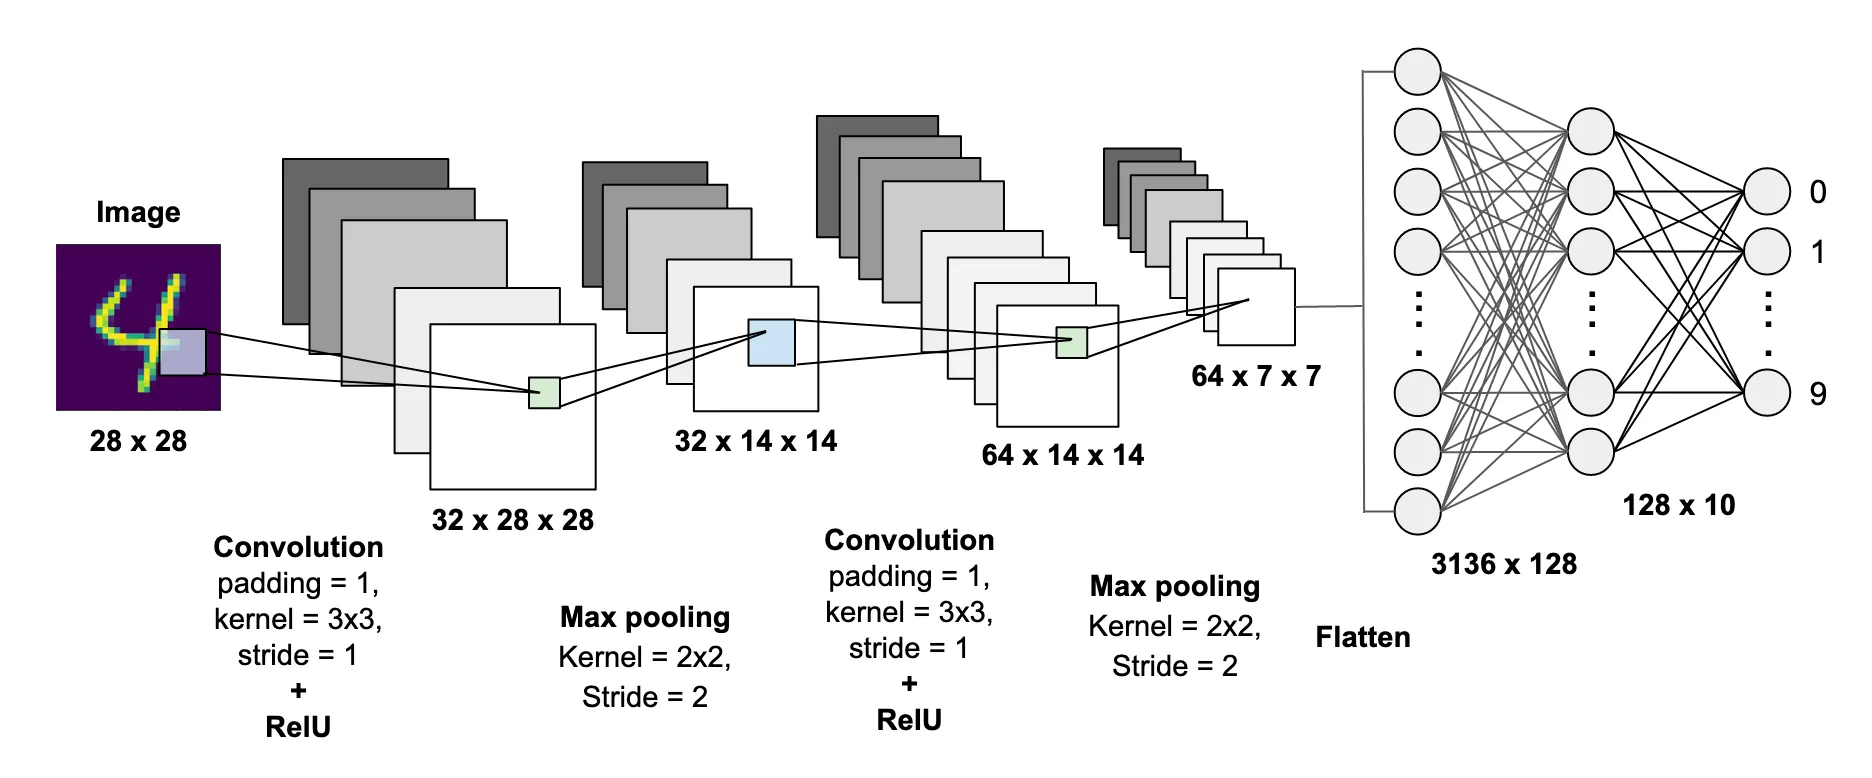
https://towardsdatascience.com/mnist-handwritten-digits-classification-using-a-convolutional-neural-network-cnn-af5fafbc35e9

* 最初の入力は28x28の画像データ。グレースケールの場合, 28x28の行列になっていて,行列の成分が座標(ピクセル)の明るさを表す。

  カラー画像の場合はR,G,Bの分、つまり、グレースケールの画像が3枚入力されることに相当する。

* 畳み込み層は後で説明する畳み込み演算を行う層である。畳み込み演算は画像処理でよく使われる演算で、画像の特徴を抽出するために使われる。

  チャンネル数個(ここでは32個)のフィルタを使って繰り返し畳み込み演算を行う。32枚の"画像"を次の層に渡す。

  Relu関数は活性化関数と呼ばれる関数でピクセル値を、正ならばそのまま、負であればゼロにして返す。

* プーリング層は画像のサイズを縮小する層である。プーリング層では、画像を分割して各領域の最大値を取ることで画像のサイズを縮小する。
　ここでは2x2の領域に分割して最大値を取ることで、画像のサイズが28x28から14x14に縮小される。

* 畳み込み層とプーリング層を繰り返す。畳み込み層のチャンネル数は64に増やしている。

* フラットニング層は画像データ(2次元データ)をベクトルに変換する層である。

* 全結合層は前の層の全てのノードと結合している。難しく聞こえるかもしれないが, 実際の演算は線形変換(行列の掛け算)とRelu関数の適用である。

* 最後の出力層は答えを出力する層である。ここでは0から9の文字を認識するために出力が10個ある。
  10個の出力を各数字のスコアとみなし、スコアの最も高かった数字をがネットワークの予測結果となる。

### 畳み込み演算

畳み込み演算はフィルタと呼ばれる行列(ここでは3x3の行列)を画像の上をスライドさせながら、フィルタの要素と画像の対応する要素の積を取り、その総和を計算する。

実際にはバイアスと呼ばれる定数項を総和に加える。

3x3の行列と定数項で10個のパラメータを持つ。

横縦とフィルタを動かしていき、畳み込み演算(+ReLU)の結果を新たな"ピクセル値"とみなす。

https://qiita.com/kenichiro-yamato/items/60affeb7ca9f67c87a17

入力チャンネルに複数の画像がある場合、それぞれの画像に対して畳み込み演算を行い、その結果を足し合わせる。

その際、 フィルタは入力画像ごとに変える。バイアスは固定。

一つのチャンネルではずっと同じ行列(フィルタ)を画像の様々な場所に畳み込み演算することで、学習後のフィルタは画像の特徴を抽出するようになる。

フィルタを変えながら画像を何度も画像を生成することで、異なる特徴が強調された画像を生成している。

一般に画像データのみだと畳み込み演算の結果出てくる画像は元の画像よりも小さくなるため、画像のサイズを維持したい場合は画像の周りに0を埋める(パディング)操作を行う。

### pytorchを使ったCNNの構成

In [ ]:
# CNNの定義
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d( 1, 32, kernel_size=(3,3), stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=(3,3), stride=1, padding=1)
        self.dropout1 = nn.Dropout2d(0.25)
        self.dropout2 = nn.Dropout2d(0.5)
        self.fc1 = nn.Linear(64*7*7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = nn.functional.relu(x)
        x = nn.functional.max_pool2d(x, 2)
        x = self.conv2(x)
        x = nn.functional.relu(x)
        x = nn.functional.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = nn.functional.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = nn.functional.log_softmax(x, dim=1)
        return output

In [ ]:
model = Net()
summary(model,(1,28,28))

1つ目の畳み込み層のパラメータは32*(3\*3+1) = 320個である。

2つ目の畳み込み層のパラメータは64*(32\*3\*3+1) = 18496個である。

全結合層1つ目のパラメータは7\*7\*64\*128+128 = 401536個である。

全結合層2つ目のパラメータは128\*10+10 = 1290個である。

実際は上の通りパラメータの数を数えてくれるので自分で数える必要はない。

## CNNを学習させる

#### データの読み込みと整形処理

In [ ]:
# Transformations to apply to the images
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download and load the training and test datasets
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)

# Function to load and preprocess the custom image
def preprocess_image(image_path):
    image = Image.open(image_path).convert('L')  # Convert to grayscale
    image = image.resize((28, 28))  # Resize to 28x28
    image = np.array(image)
    image = (image - 0.1307) / 0.3081  # Normalize
    image = np.expand_dims(image, axis=0)  # Add channel dimension
    image = np.expand_dims(image, axis=0)  # Add batch dimension
    image = torch.tensor(image, dtype=torch.float32)  # Convert to tensor
    return image

# Function to make a prediction on a custom image
def predict_custom_image(model, device, image_path):
    model.eval()
    image = preprocess_image(image_path).to(device)
    with torch.no_grad():
        output = model(image)
        pred = output.argmax(dim=1, keepdim=True)
        return pred.item()


#### ロス関数と最適化の定義

lrは学習率である。大きいほど計算は早くなるが、収束しないことがある。小さいほど計算は遅くなるが、収束することが多い。

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0005)#ここの数字を変えてみる

学習済みのネットワークを読み込んで再度学習を進める場合は次のセルをアンコメントアウトして実行する

In [ ]:
#load the model
#model.load_state_dict(torch.load('mnist_cnn.pth'))

#### 学習過程の実装

In [ ]:
# Training loop
def train(model, device, train_loader, optimizer, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} ({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')

# Testing loop with plotting
def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    test_images = []
    test_predictions = []
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            test_images.extend(data.cpu().numpy())
            test_predictions.extend(pred.cpu().numpy())

    test_loss /= len(test_loader.dataset)
    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({100. * correct / len(test_loader.dataset):.0f}%)\n')
    
    #各エポックでの正答率が見たい場合はここをアンコメントアウトする
    #ここから
    #fig, axes = plt.subplots(3, 3, figsize=(9, 9))
    #axes = axes.flatten()
    #for i, ax in enumerate(axes):
    #    img = test_images[i][0]
    #    ax.imshow(img, cmap='gray')
    #    ax.set_title(f'Prediction: {test_predictions[i][0]}')
    #    ax.axis('off')
    #plt.tight_layout()
    #ここまで


#### 学習の実行

エポック数は学習データを何周するかを決める。

In [ ]:
# Train and test the model

#google colaraboratoryの場合などcudaが使える場合は上を使う
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

print(f'Using device: {device}')
model.to(device)

for epoch in range(1, 10): #ここのループサイズを変更する
    train(model, device, train_loader, optimizer, epoch)
    test(model, device, test_loader)

torch.save(model.state_dict(), 'mnist_cnn.pth')

### 学習させたCNNを使って手書き文字を分類してみる

In [ ]:
#load the model
model.load_state_dict(torch.load('mnist_cnn.pth'))

# Plotting some of the test images with their predictions
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
axes = axes.flatten()
for i, ax in enumerate(axes):
    custom_image_path = './test/test_'+format(i+1)+'.png'  # Replace with your image path
    image = Image.open(custom_image_path).convert('L')  # Convert to grayscale
    image = image.resize((28, 28))  # Resize to 28x28
    image = np.array(image)
    predicted_label = predict_custom_image(model, device, custom_image_path)
    ax.imshow(image, cmap='gray')
    ax.set_title(f'Prediction: {predicted_label}')
    ax.axis('off')
plt.tight_layout()
plt.show()


### 課題I

* 学習率を大きくしすぎると学習が進まなくなる(lossが下がらない)ことを確認せよ。

* 学習率を元に戻し, エポック数を変えて学習進捗を確認せよ。

* testフォルダの手書き文字を綺麗な文字に変えて、学習済みネットワークに入力して正しく分類されるか確認せよ。

#### 任意課題

* image_classification_input.pyにカラー画像の場合を用意したのでnum_epochs = 10を大きい数字に変更して、学習の様子を観察してみよ。


# Generative Adversarial Network

Generative Adversarial Network (GAN)は生成モデル、もしくは生成AI呼ばれるものの一つで、先ほど学んだCNNを用いて画像を生成させるネットワークモデルである。

GANの構造を以下に示す。

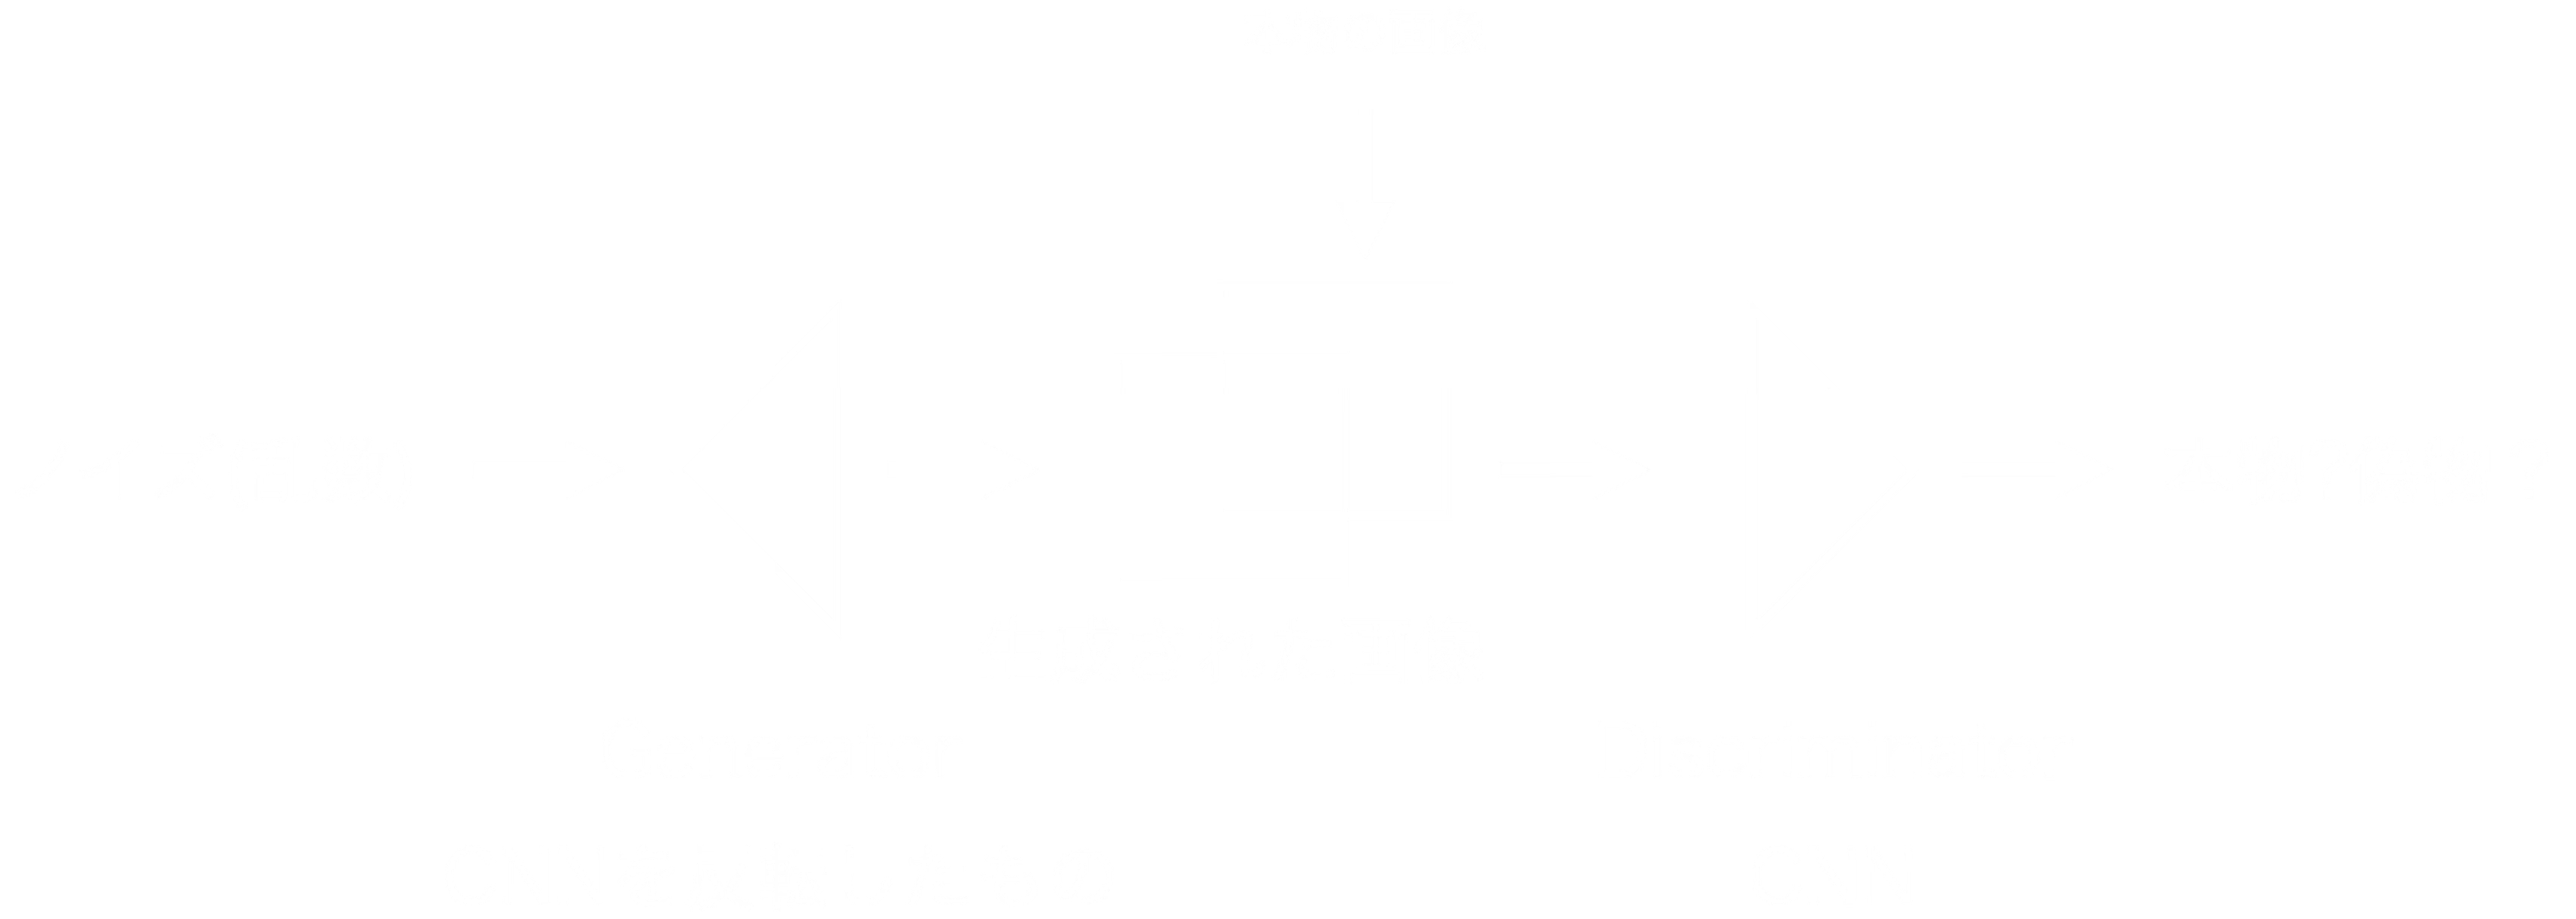

* Discriminatorは先程と同じCNNで画像もしくは偽物の画像が入力され、入力された画像が本物であるか偽物であるかを答えさせる構造になっている

* GeneratorはCNNのネットワーク構造を反転させたネットワークで、ベクトルが入力されると、画像と同じデータ（テンソル）が出力される

* GANはDiscriminatorとGeneratorの学習を交互に進めていき、つまり、Discriminatorは本物を本物、偽物を偽物と精度良く答えられるように、GeneratorはDiscriminatorの失敗確率が上がるようにニューラルネットワークのパラメータをそれぞれ最適化する。

    学習が終わった後のGeneratorにノイズを入れれば、中間に入力していた画像によく似た画像を生成できるようになる。

* 構造が簡単なので教材として使ったが最近は他の生成モデルが主流のようである。

## GANの実装

In [23]:
# Hyperparameters
image_size = 32
batch_size = 16
latent_dim = 10
ratio = 1
#以下のパラメータを変えてみる
learning_rate = 0.0001
num_epochs = 200 ##2~3時間かかるので注意

ネットワークの定義

In [24]:
# Generator model
class Generator(nn.Module):
    def __init__(self, input_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, image_size *image_size),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.model(x)
        x = x.view(x.size(0), 1, image_size, image_size)
        return x

# Discriminator model
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(image_size * image_size, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.model(x)
        return x


In [25]:
current_step=0

In [26]:
def generate_images(epoch, generator, latent_dim, num_images=25, image_size=(1, image_size, image_size)):

    with torch.no_grad():
        z = torch.randn(num_images, latent_dim).to(device)
        generator.eval()
        fake_images = generator(z)
        fake_images = fake_images.view(fake_images.size(0), *image_size)
        fake_images = (fake_images + 1) / 2.0  # Rescale to [0, 1]
        fake_images = fake_images.cpu().detach().numpy()
    
    fig, axes = plt.subplots(5, 5, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake_images[i][0], cmap='gray')
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'./generated_images/generated_images_epoch_{epoch}.png')
    #plt.show()
    plt.close()


以下を実行する（クリックする）度に学習が進み徐々に手書き文字に似た画像が生成されるようになる

epoch数100で実行すると2~3時間かかります

generated_imagesフォルダに学習の各エポックで生成された画像が保存されているので、実行が終わった後に確認してください

In [27]:
# Device configuration
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

# Data preprocessing
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# MNIST dataset
mnist = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
data_loader = DataLoader(dataset=mnist, batch_size=batch_size, shuffle=True)

# Initialize models
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

# Loss and optimizer
criterion = nn.BCELoss() # binary cross entropy
optimizer_G = optim.AdamW(generator.parameters(), lr=learning_rate)
optimizer_D = optim.AdamW(discriminator.parameters(), lr=learning_rate)

if os.path.exists('generator.pth')==1:
    generator.load_state_dict(torch.load('generator.pth'))
    discriminator.load_state_dict(torch.load('discriminator.pth'))

# Training the GAN
for epoch in range(num_epochs):
    generator.train()
    discriminator.train()

    tot_d_loss=0.0
    tot_g_loss=0.0
    tot_real_score=0.0
    tot_fake_score=0.0

    for i, (images, _) in enumerate(data_loader):
        batch_size = images.size(0)
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)
        
        # Train Discriminator
        optimizer_D.zero_grad()
        outputs = discriminator(images.to(device))
        d_loss_real = criterion(outputs, real_labels)
        real_score = outputs

        z = torch.randn(batch_size, latent_dim).to(device)
        fake_images = generator(z)
        outputs = discriminator(fake_images.detach())
        d_loss_fake = criterion(outputs, fake_labels)
        fake_score = outputs

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()
        tot_d_loss+=d_loss.item()

        # Train Generator
        if epoch%ratio==0:
            optimizer_G.zero_grad()
            z = torch.randn(batch_size, latent_dim).to(device)
            fake_images = generator(z)
            outputs = discriminator(fake_images)
            g_loss = criterion(outputs, real_labels)

            g_loss.backward()
            optimizer_G.step()
            tot_g_loss+=g_loss.item()

        tot_real_score+=real_score.mean().item()
        tot_fake_score+=fake_score.mean().item()

        if (i+1) % 250 == 0:  # print every 250 mini-batches
            print(f'Epoch [{epoch+1}/{num_epochs}], '
                  f'D Loss: {tot_d_loss/250:.4f}, G Loss: {tot_g_loss/250:.4f}, '
                  f'D(x): {tot_real_score/250:.4f}, D(G(z)): {tot_fake_score/250:.4f}')
            
            tot_d_loss=0.0
            tot_g_loss=0.0
            tot_real_score=0.0
            tot_fake_score=0.0


    if epoch%ratio==0:
        # Generate new images
        generate_images(current_step+epoch+1, generator, latent_dim)

# Save the models
torch.save(generator.state_dict(), 'generator.pth')
torch.save(discriminator.state_dict(), 'discriminator.pth')
current_step+=num_epochs


Using device: mps
Epoch [1/200], D Loss: 0.8328, G Loss: 1.5321, D(x): 0.8316, D(G(z)): 0.4036
Epoch [1/200], D Loss: 1.1755, G Loss: 1.7976, D(x): 0.6721, D(G(z)): 0.4150
Epoch [1/200], D Loss: 1.1685, G Loss: 1.2949, D(x): 0.6219, D(G(z)): 0.4288
Epoch [1/200], D Loss: 1.2043, G Loss: 1.1367, D(x): 0.6422, D(G(z)): 0.4508
Epoch [1/200], D Loss: 1.2189, G Loss: 1.1117, D(x): 0.6263, D(G(z)): 0.4538
Epoch [1/200], D Loss: 1.2198, G Loss: 1.0762, D(x): 0.6088, D(G(z)): 0.4508
Epoch [1/200], D Loss: 1.1747, G Loss: 1.0519, D(x): 0.6190, D(G(z)): 0.4389
Epoch [1/200], D Loss: 1.0901, G Loss: 1.3149, D(x): 0.6679, D(G(z)): 0.4030
Epoch [1/200], D Loss: 0.8793, G Loss: 1.9185, D(x): 0.7316, D(G(z)): 0.3044
Epoch [1/200], D Loss: 0.9407, G Loss: 1.7939, D(x): 0.7252, D(G(z)): 0.3141
Epoch [1/200], D Loss: 0.7967, G Loss: 1.8900, D(x): 0.7607, D(G(z)): 0.2725
Epoch [1/200], D Loss: 0.7982, G Loss: 2.0936, D(x): 0.7649, D(G(z)): 0.2695
Epoch [1/200], D Loss: 0.7042, G Loss: 2.2897, D(x): 0.789

やり直して学習の経過をもう一度見たい場合はgenerator.pthとdiscriminator.pthを削除する

ここで作ったGANは乱数を入力$\rightarrow$ 0から9の数字のどれかを生成するようになっている

もし、数字をこちらで指定して、指定した数字を生成させたい場合はconditional GANというものを実装する必要がある (ここでは取り扱わない)

### 学習済みのモデルで繰り返し画像を生成したいときは以下を実行する

Using device: mps


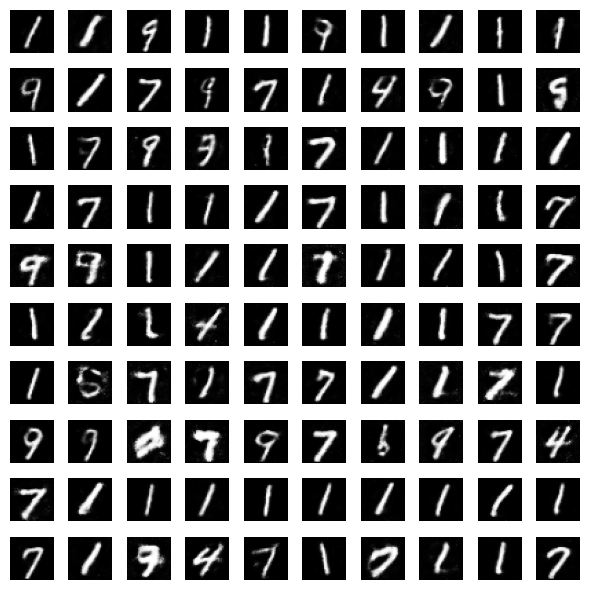

In [34]:
# Device configuration
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

# Data preprocessing
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Initialize models
generator = Generator(latent_dim).to(device)

if os.path.exists('generator.pth')==1:
    generator.load_state_dict(torch.load('generator.pth'))
    discriminator.load_state_dict(torch.load('discriminator.pth'))

def generate_images(generator, latent_dim, num_images=100, image_size=(1, image_size, image_size)):

    with torch.no_grad():
        z = torch.randn(num_images, latent_dim).to(device)
        generator.eval()
        fake_images = generator(z)
        fake_images = fake_images.view(fake_images.size(0), *image_size)
        fake_images = (fake_images + 1) / 2.0  # Rescale to [0, 1]
        fake_images = fake_images.cpu().detach().numpy()
    
    fig, axes = plt.subplots(10, 10, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake_images[i][0], cmap='gray')
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close()

# Generate new images
generate_images(generator, latent_dim)

# 課題II

* 学習が進むにつれて文字が生成されていく様子を確認せよ

    十分に良い精度で画像が生成できるようにするには何回もエポック(~100)を進める必要があります 

    できる範囲で試してみください

# Long Short Term Memory

最後に時系列でた扱うニューラルネットワークであるLong Short Term Memory (LSTM)を紹介する。

LSTMはRecurrent Neural Network (RNN)の特別な場合で、パーフォーマンスはこちらの方が良いとされているので、ここではLSTMを扱う。

時系列データのみでなく、遺伝配列の解析や文章翻訳、映画に字幕をつけるなどなどデータに前後の情報(文脈)があるデータ全般に応用が可能である。

まずはRNNの構造を見てみよう

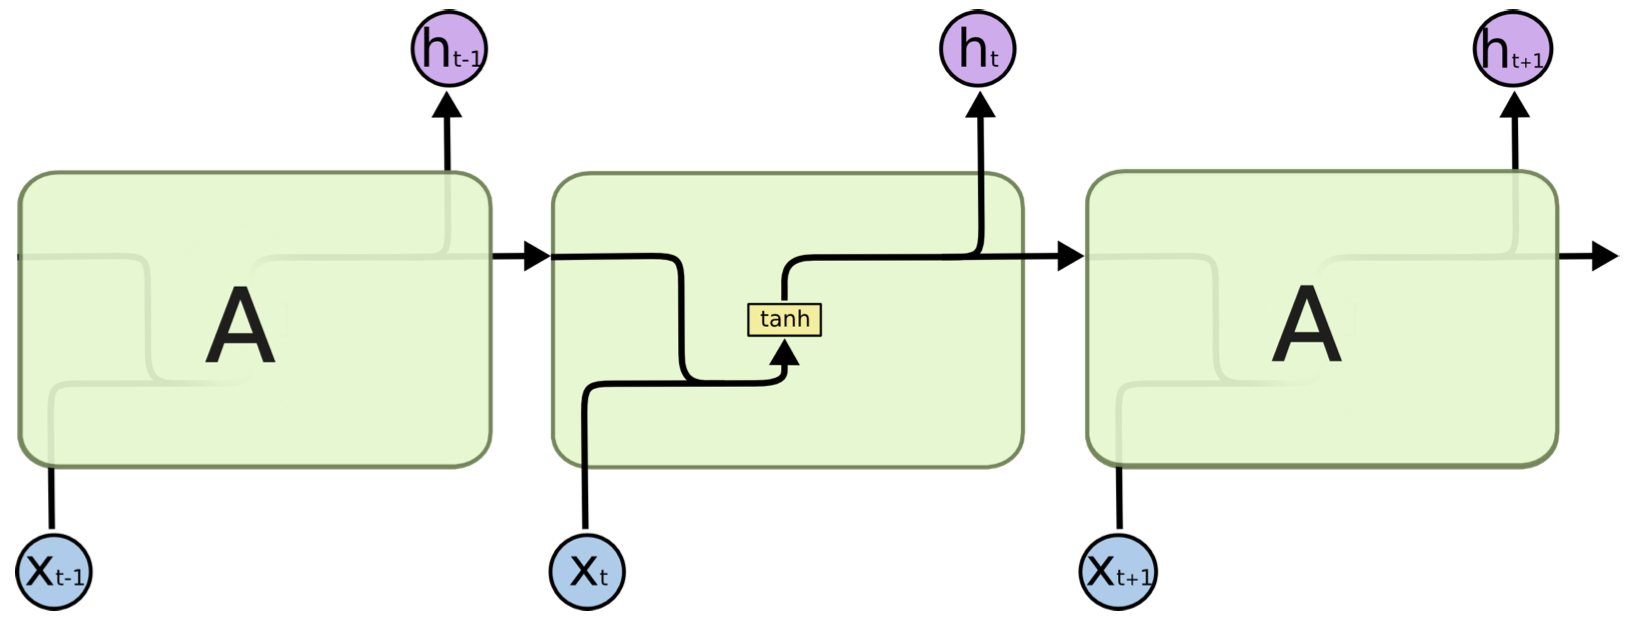

https://web.stanford.edu/class/cs379c/archive/2018/class_messages_listing/content/Artificial_Neural_Network_Technology_Tutorials/OlahLSTM-NEURAL-NETWORK-TUTORIAL-15.pdf

{x}が入力される時系列データで、{h}がそれに基づく予測データである。

各Aがネットワークのブロック(基本的にCNNと同じ)で、現在の時系列データの入力と一つ前のネットワークからの入力を受け、予測データの出力と、次のネットワークへの情報の出力を行う。

実際にはtanhのところにもっと複雑な演算が入るが、基本的にはCNNで見た演算と同じである。

このようにしてRNNは時系列情報を上手く活用することができる。

しかしながら、非常に時間が離れた場合 ($x_0$と$h_{100}$など)、入力の情報はネットワークを何度も通ってから予測に使われるため、情報がなかなか伝わらなくなる。

基本的に全結合層を通すと計算効率が良くないので、CNNのときのように事前にデータの構造が明らかな場合は、ネットワークもその構造を反映した形にするのが良い。

今の場合、過去の情報が直接、現在の推論に使われるような(かつ不要な場合は消せる)構造があると望ましい。

次にLSTMの構造を見てみよう

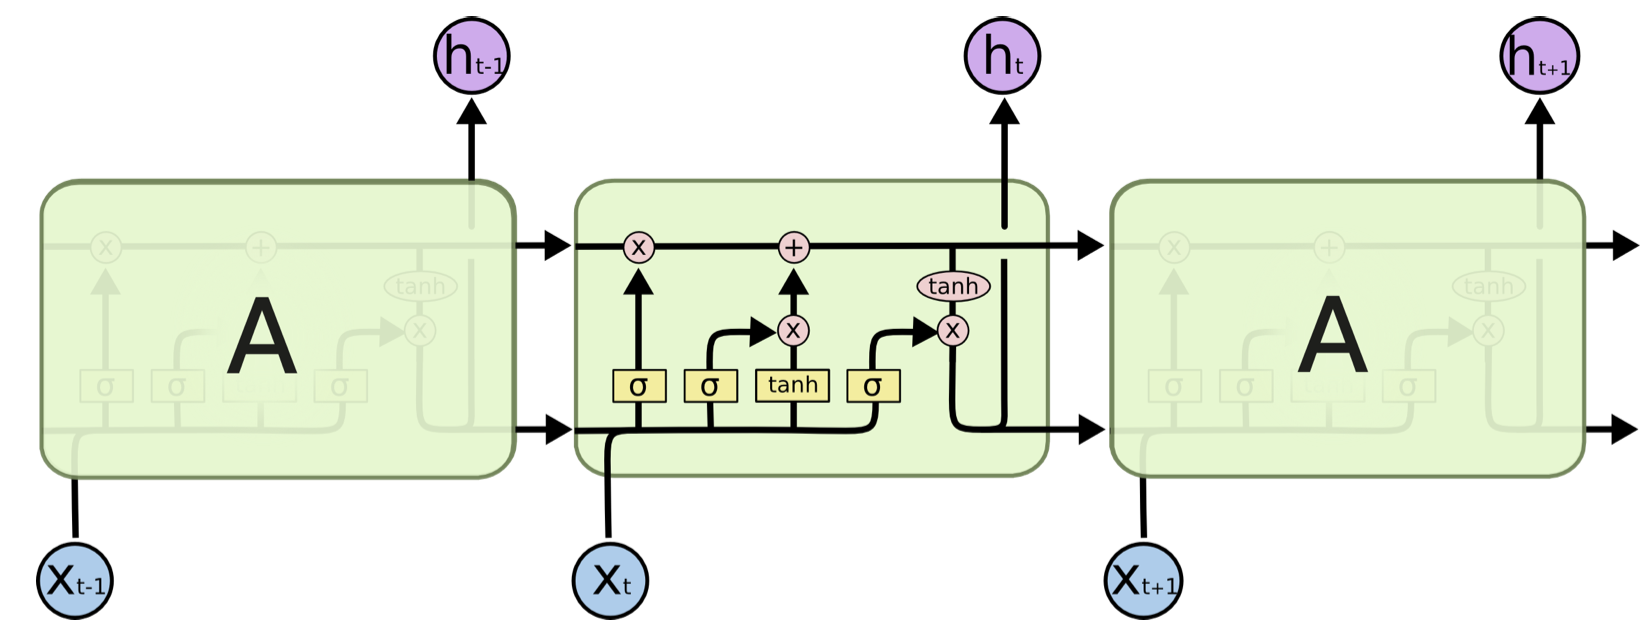

https://web.stanford.edu/class/cs379c/archive/2018/class_messages_listing/content/Artificial_Neural_Network_Technology_Tutorials/OlahLSTM-NEURAL-NETWORK-TUTORIAL-15.pdf

先程のRNNとの違いは前のネットワークから直接履歴を引き継ぐパスが追加されていることである。

非常に大雑把にであるが、RNNの演算をするパスをタスクの実行を行うパスと、記憶の引き継きつぎを行うパスに分けたRNNがLSTMである。

上段のパスでは過去の記憶の消去、追加などの演算が行われる。

下段のパスは先程と同様にRNNによる出力(時系列データ解析の場合は予言)の演算が行われる。

## corvid19の時系列データの学習と感染者の推移の予測

時系列データをネットワークにフィットするように整形する

In [ ]:
# Load the dataset
actual_data = pd.read_csv('data20230505-20200120.csv')
actual_data = actual_data.sort_values('time')
data = actual_data['infected']

# Preprocessing
# 時系列データをネットワークのインプットに適合するようにリスケールする
scaler = MinMaxScaler(feature_range=(-1, 1))
data_normalized = scaler.fit_transform(data.values.reshape(-1, 1))

def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data) - seq_length):
        x = data[i:i + seq_length] #時刻iから時刻i+seq_length-1までのデータセット (学習値)
        y = data[i + seq_length] #i+seq_lengthのデータセット (予測値)
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

# !!ここを編集する!!
seq_length = 10
X, y = create_sequences(data_normalized, seq_length)
#Xの中身は [x_0,...,x_9], [x_1,...,x_10], .... (学習値)
#Yの中身は [x_10], [x_11], .... (予測値)
#10日間の感染者数から11日目の感染者数を予測させるLSTMを作る
#(学習値,予測値)のデータセットは1日ずつずらすことで生成する

# Function to select training interval
def select_training_interval(X, y, start, end):
    return X[start:end], y[start:end]

# !!ここを編集する!!
# Choose start and end points of the training interval
start, end = 400, 800  # Modify these values as needed

X_train, y_train = select_training_interval(X, y, start, end) #学習に使うインターバル
X_test, y_test = X[end:], y[end:] #予測するインターバル

# Convert data to tensors
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()
X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test).float()

ネットワークの定義

In [ ]:
class LSTM(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=100, output_size=1):
        super(LSTM, self).__init__()
        self.hidden_layer_size = hidden_layer_size
        self.lstm = nn.LSTM(input_size, hidden_layer_size)
        self.linear = nn.Linear(hidden_layer_size, output_size)
        self.hidden_cell = (torch.zeros(1, 1, self.hidden_layer_size),
                            torch.zeros(1, 1, self.hidden_layer_size))

    def forward(self, input_seq):
        lstm_out, self.hidden_cell = self.lstm(input_seq.view(len(input_seq), 1, -1), self.hidden_cell)
        predictions = self.linear(lstm_out.view(len(input_seq), -1))
        return predictions[-1]

#### 学習を実行する

In [ ]:
model = LSTM()
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

#train the model

epochs = 200
for i in range(epochs):
    for seq, labels in zip(X_train, y_train):
        optimizer.zero_grad()
        model.hidden_cell = (torch.zeros(1, 1, model.hidden_layer_size),
                             torch.zeros(1, 1, model.hidden_layer_size))

        y_pred = model(seq)

        single_loss = loss_function(y_pred, labels)
        single_loss.backward()
        optimizer.step()

    if i % 10 == 0:
        print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')

print(f'epoch: {i:3} loss: {single_loss.item():10.10f}')

# Make predictions
model.eval()
test_predictions = []

for seq in X_test:
    with torch.no_grad():
        model.hidden_cell = (torch.zeros(1, 1, model.hidden_layer_size),
                             torch.zeros(1, 1, model.hidden_layer_size))
        test_predictions.append(model(seq).item())

test_predictions = scaler.inverse_transform(np.array(test_predictions).reshape(-1, 1))
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)) #元の時系列データの形式に戻す

plt.figure(figsize=(10, 6))
plt.plot(range(len(data_normalized)), scaler.inverse_transform(data_normalized), label='True Data')
plt.plot(range(len(data_normalized))[start:end], scaler.inverse_transform(data_normalized)[start:end], label='Used for learning')
plt.plot(range(len(data_normalized) - len(test_predictions), len(data_normalized)), test_predictions, label='Predictions')
plt.legend()
plt.show()


# 課題III

* 学習させるインターバル, seq_lengthを変えて実行する

#### 任意課題

* 機械学習による時系列予測と数理モデル(SIR方程式など)に基づく時系列予測のコストについて考察する


# レポート課題

1.）上記課題I,II,IIIを実行せよ (任意課題はやらなくても良い)

2.）実行結果をまとめてレポートにせよ

レポートについて
1)	題名は「Pythonプログラミングと機械学習」として、ここで述べた課題を全て含むようにしてまとめ、1つのファイルにしてK-LMSから提出せよ

2)	レポートのファイル名例：

    14B99慶応太郎pythonコメントがあれば記載.pdf

3)	締め切りは2025年1月31日(火)

4)	出来ない問・課題に対しては出来ない理由を考察し、全ての問・課題に対して答えよ

5)	友人・知人と相談してもよいし実験を手伝ってもらってもよい、他人のレポートを参照しても良い。他人の世話になった時には、世話になった個所を明記し、謝辞に記載すること。他人の世話になってもよいのは、物理学実験独自の規則であり、他科目は違うから気を付けること